#Wine Quality Analysis - Data Analysis Project

## Project Goal
Analyze the relationship among variables(fixed acidity, volatile acidity, citric acid, and etc) and the quality of wines to find the most relevant impact on wine quality.

## Dataset
- Input variables: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, and alcohol
- Output variables: quality

## Tools
- Python, pandas, numpy, matplotlib, seaborn, scipy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 1. Exploratory Data Analysis (EDA)

In [2]:
print("=== basic Info ===")
print("Shape: ", df.shape)
print("\nData Types: ")
print(df.dtypes)
print("\nBasic Statictics: ")
print(df.describe())
print("\nMissing Values: ")
print(df.isnull().sum())

=== basic Info ===
Shape:  (1599, 12)

Data Types: 
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Basic Statictics: 
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.6

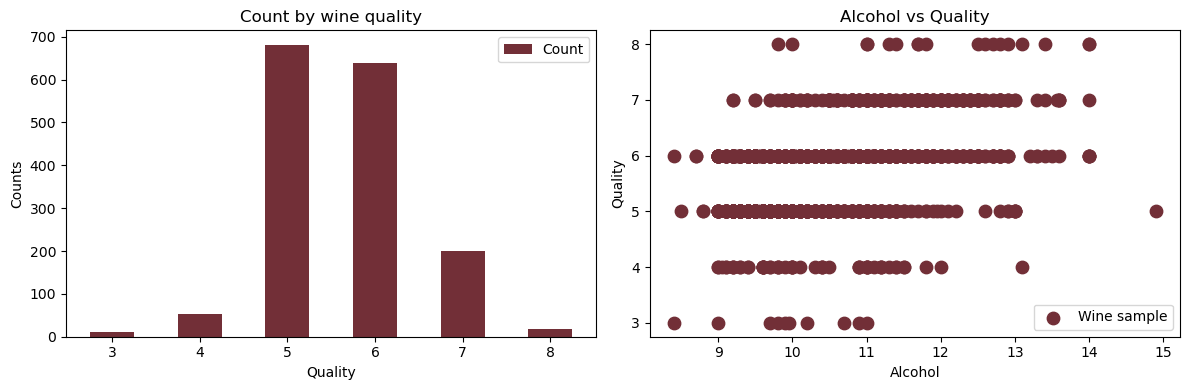

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

quality_counts = df['quality'].value_counts().sort_index()

axes[0].bar(quality_counts.index, quality_counts.values,
             color='#722F37', width=0.5, label='Count')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Counts')
axes[0].set_title('Count by wine quality')
axes[0].legend()

axes[1].scatter(df['alcohol'], df['quality'],
                 color='#722F37', s=80, zorder=5, label='Wine sample')
axes[1].set_xlabel('Alcohol')
axes[1].set_ylabel('Quality')
axes[1].set_title('Alcohol vs Quality')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Correlation Analysis

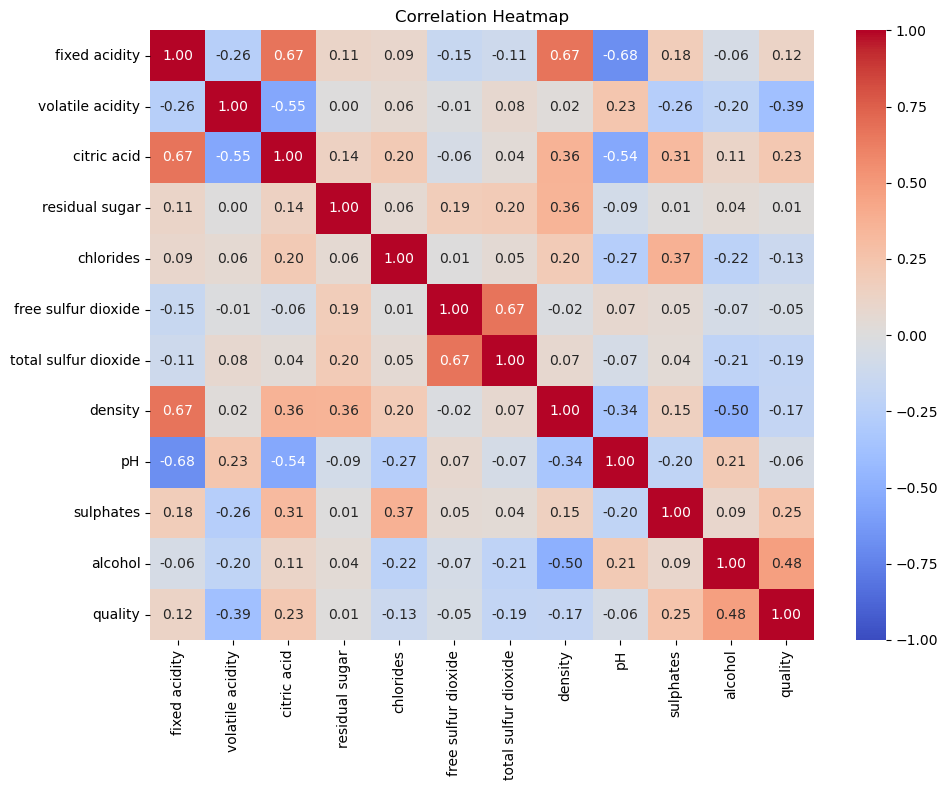

In [8]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

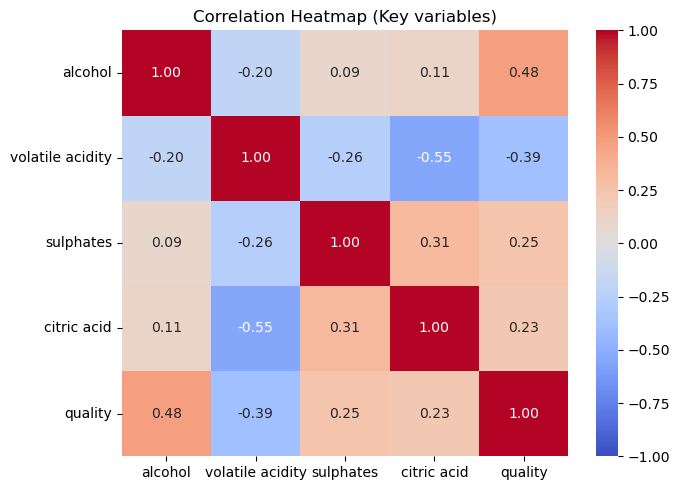

Alcohol vs Quality:
  r = 0.476, p-value = 0.0000
  → Statistically significant (p < 0.05)


In [11]:
corr = df[['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Key variables)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

r,p = stats.pearsonr(df['alcohol'], df['quality'])
print(f"Alcohol vs Quality:")
print(f"  r = {r:.3f}, p-value = {p:.4f}")
print(f"  → {'Statistically significant (p < 0.05)' if p < 0.05 else 'Not significant'}")

## 3. Linear Regression Analysis

=== Linear Regression Results ===
Equation: quality = 0.36 x alcohol + 1.87
R²: 0.227
p_value: 0.0000


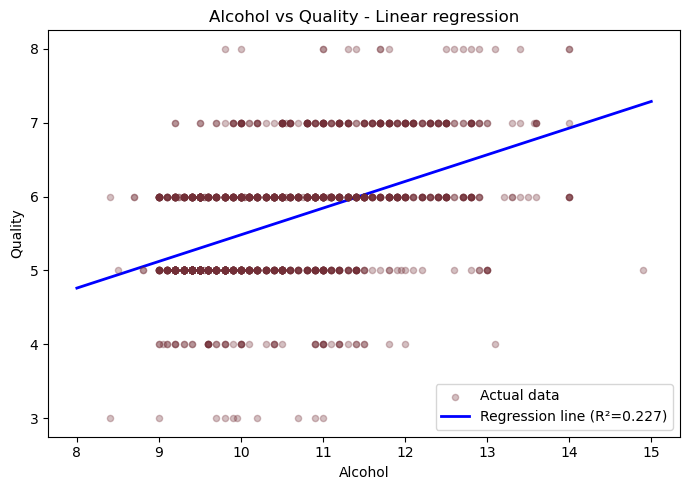

In [14]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['alcohol'], df['quality'])

print("=== Linear Regression Results ===")
print(f"Equation: quality = {slope:.2f} x alcohol + {intercept:.2f}")
print(f"R²: {r_value**2:.3f}")
print(f"p_value: {p_value:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['alcohol'], df['quality'], 
           color='#722F37', s=20, alpha=0.3, zorder=5, label='Actual data')

x_line = np.linspace(8, 15, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='blue', linewidth=2,
        label=f'Regression line (R²={r_value**2:.3f})')

ax.set_xlabel('Alcohol')
ax.set_ylabel('Quality')
ax.set_title('Alcohol vs Quality - Linear regression')
ax.legend()
plt.tight_layout()
plt.savefig('regression_plot.png', dpi=150, bbox_inches='tight')
plt.show()